[info] Using target column: Survival_Prediction
[info] Subsampled CRC to 5000 rows for Week 2 runtime.
[labels overall] {1: 2998, 0: 2002}
[split] test_size=0.2, seed=42

=== Week 2 — CRC Results ===
Dataset: CRC
BestParams: {'model__C': 1}
AUC_ROC: 0.5444708333333332
AUPRC: 0.6407675867912834
F1@0.5: 0.5644283121597096
Accuracy@0.5: 0.52
ConfusionMatrix@0.5: [[209, 191], [289, 311]]


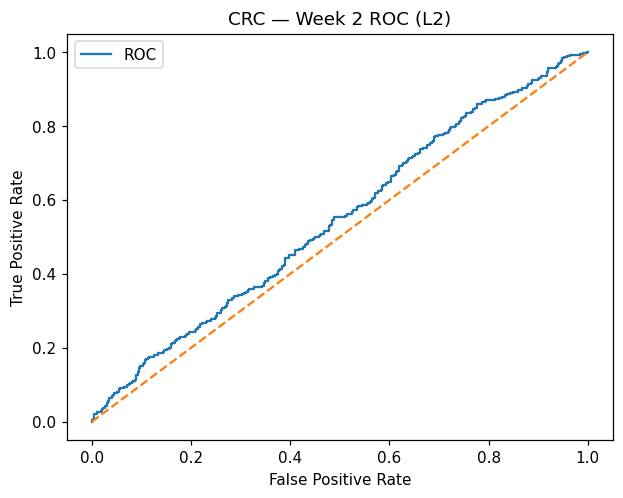

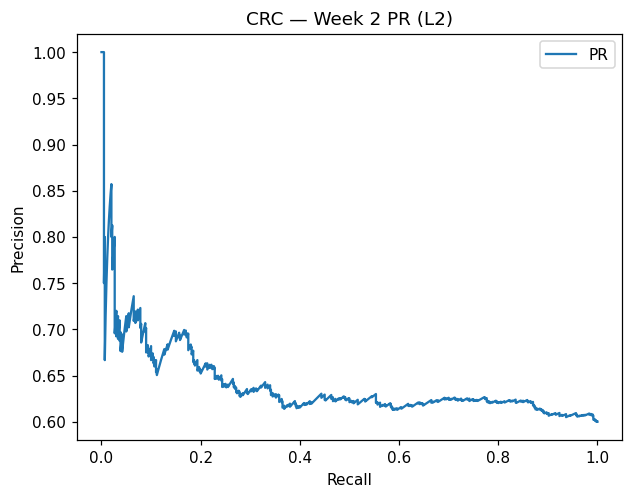

In [6]:
# Week 2 — Colorectal Cancer Only
# Logistic Regression with L2 (Ridge) Regularization + GridSearchCV


import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

plt.rcParams['figure.dpi'] = 110


CRC_PATH = "colorectal_cancer_dataset.csv"
df_crc = pd.read_csv(CRC_PATH)

# Identify target column
if "target" in df_crc.columns:
    target_col = "target"
elif "Survival_Prediction" in df_crc.columns:
    target_col = "Survival_Prediction"
elif "Diagnosis" in df_crc.columns:
    target_col = "Diagnosis"
else:
    raise ValueError(f"No obvious target found. Columns: {df_crc.columns.tolist()}")
print(f"[info] Using target column: {target_col}")

# Convert Yes/No to binary (1 = Yes, 0 = No)
y = (df_crc[target_col].astype(str).str.strip().str.lower() == "yes").astype(int)
X = df_crc.drop(columns=[target_col])

# Optional: subsample for runtime efficiency
if len(y) > 5000:
    X, _, y, _ = train_test_split(X, y, train_size=5000, stratify=y, random_state=42)
    print("[info] Subsampled CRC to 5000 rows for Week 2 runtime.")


def make_preprocessor(X_fit):
    num_cols = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_fit.columns if c not in num_cols]
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

def stratified_split_robust(X, y, init_test_size=0.2, seeds=50, random_state=42):
    vc = Counter(y.tolist())
    print("[labels overall]", dict(vc))
    if len(vc) < 2:
        raise ValueError("Only one class present in whole dataset!")
    for ts in [init_test_size, 0.15, 0.1]:
        for s in range(seeds):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=ts, stratify=y, random_state=(random_state+s)
            )
            if len(np.unique(y_tr)) == 2:
                print(f"[split] test_size={ts}, seed={random_state+s}")
                return X_tr, X_te, y_tr, y_te
    raise ValueError("Could not create split with both classes.")

def plot_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure()
    plt.plot(fpr, tpr, label="ROC")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend()
    plt.show()

def plot_pr(y_true, y_score, title):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(rec, prec, label="PR")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title); plt.legend()
    plt.show()

# Week 2 pipeline: L2-regularized Logistic Regression
X_train, X_test, y_train, y_test = stratified_split_robust(X, y, init_test_size=0.2)
pre = make_preprocessor(X_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = {"model__C": [0.01, 0.1, 1, 10, 100]}  # smaller to stronger regularization

pipe = Pipeline([
    ("pre", pre),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=4000, class_weight="balanced"))
])

gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=1)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)


metrics = {
    "Dataset": "CRC",
    "BestParams": gs.best_params_,
    "AUC_ROC": roc_auc_score(y_test, y_proba),
    "AUPRC": average_precision_score(y_test, y_proba),
    "F1@0.5": f1_score(y_test, y_pred),
    "Accuracy@0.5": accuracy_score(y_test, y_pred),
    "ConfusionMatrix@0.5": confusion_matrix(y_test, y_pred).tolist()
}

print("\n=== Week 2 — CRC Results ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

plot_roc(y_test, y_proba, "CRC — Week 2 ROC (L2)")
plot_pr(y_test, y_proba, "CRC — Week 2 PR (L2)")


[info] Using target column: Diagnosis
[labels overall] {1: 1524, 0: 135}
[split] test_size=0.2, seed=42

=== Week 2 — CKD_alt Results ===
Dataset: CKD_alt
BestParams: {'model__C': 0.01}
AUC_ROC: 0.7950212507589556
AUPRC: 0.9710346633178255
F1@0.5: 0.8385899814471243
Accuracy@0.5: 0.7379518072289156
ConfusionMatrix@0.5: [[19, 8], [79, 226]]


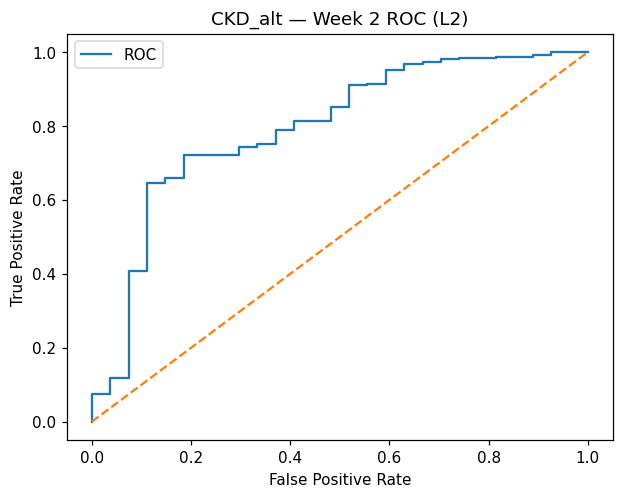

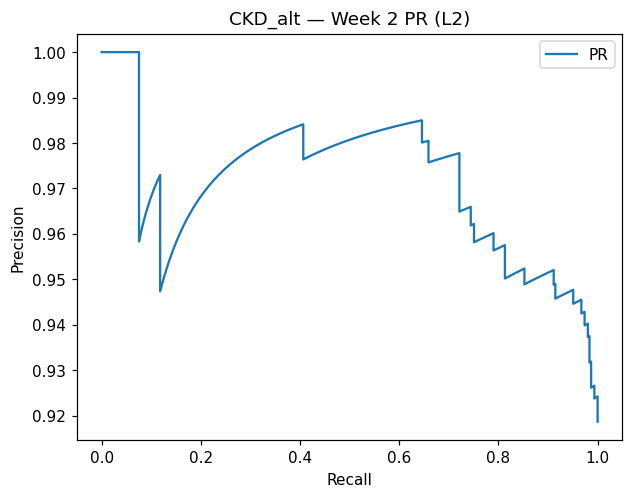

In [9]:
# Chronic_Kidney_Disease_data.csv
# Logistic Regression with L2 (Ridge) + GridSearchCV


import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

plt.rcParams['figure.dpi'] = 110


CKD_ALT_PATH = "Chronic_Kidney_Disease_data.csv"
df = pd.read_csv(CKD_ALT_PATH)

# Target column: typically 'Diagnosis' (0/1). Fallback to 'class' if needed.
if "Diagnosis" in df.columns:
    target_col = "Diagnosis"
elif "class" in df.columns:
    target_col = "class"
else:
    raise ValueError(f"No obvious target found. Columns: {df.columns.tolist()}")
print(f"[info] Using target column: {target_col}")

# Binary target as ints
y = df[target_col].astype(int)
# Drop target and obvious identifiers/leakage if present
drop_cols = [target_col] + [c for c in ["DoctorInCharge", "PatientID"] if c in df.columns]
X = df.drop(columns=drop_cols)

def make_preprocessor(X_fit):
    num_cols = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_fit.columns if c not in num_cols]
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

def stratified_split_robust(X, y, init_test_size=0.2, seeds=50, random_state=42):
    vc = Counter(y.tolist())
    print("[labels overall]", dict(vc))
    if len(vc) < 2:
        raise ValueError("Only one class present in the whole dataset!")
    for ts in [init_test_size, 0.15, 0.1]:
        for s in range(seeds):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=ts, stratify=y, random_state=(random_state+s)
            )
            if len(np.unique(y_tr)) == 2:
                print(f"[split] test_size={ts}, seed={random_state+s}")
                return X_tr, X_te, y_tr, y_te
    raise ValueError("Could not create a split with both classes. Try smaller test size.")

def plot_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure()
    plt.plot(fpr, tpr, label="ROC")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend()
    plt.show()

def plot_pr(y_true, y_score, title):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(rec, prec, label="PR")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title); plt.legend()
    plt.show()

# Week 2: L2-regularized Logistic Regression (+CV)
X_train, X_test, y_train, y_test = stratified_split_robust(X, y, init_test_size=0.2)
pre = make_preprocessor(X_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = {"model__C": [0.01, 0.1, 1, 10, 100]}  # stronger → weaker regularization

pipe = Pipeline([
    ("pre", pre),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=4000, class_weight="balanced"))
])

gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=1)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)


metrics = {
    "Dataset": "CKD_alt",
    "BestParams": gs.best_params_,
    "AUC_ROC": roc_auc_score(y_test, y_proba),
    "AUPRC": average_precision_score(y_test, y_proba),
    "F1@0.5": f1_score(y_test, y_pred),
    "Accuracy@0.5": accuracy_score(y_test, y_pred),
    "ConfusionMatrix@0.5": confusion_matrix(y_test, y_pred).tolist()
}

print("\n=== Week 2 — CKD_alt Results ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

plot_roc(y_test, y_proba, "CKD_alt — Week 2 ROC (L2)")
plot_pr(y_test, y_proba, "CKD_alt — Week 2 PR (L2)")


[info] Using target column: class
[labels overall] {1: 128, 0: 72}
[split] test_size=0.2, seed=42

=== Week 2 — CKD_v2 Results ===
Dataset: CKD_v2
BestParams: {'model__C': 0.01}
AUC_ROC: 0.9972527472527473
AUPRC: 0.9985754985754985
F1@0.5: 0.9803921568627451
Accuracy@0.5: 0.975
ConfusionMatrix@0.5: [[14, 0], [1, 25]]


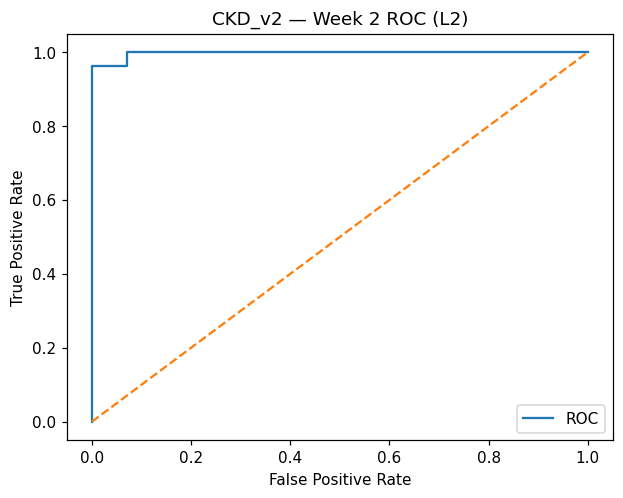

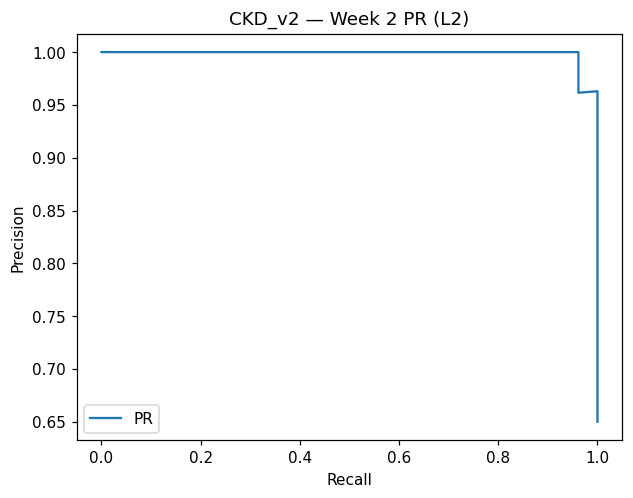

In [11]:

# ckd-dataset.csv
# Logistic Regression with L2 (Ridge) + GridSearchCV


import numpy as np, pandas as pd, matplotlib.pyplot as plt, re
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

plt.rcParams['figure.dpi'] = 110

#Load Dataset
CKD_V2_PATH = "ckd-dataset.csv"
df = pd.read_csv(CKD_V2_PATH)

# Target handling: prefer 'class'; fallback to common aliases if needed
if "class" in df.columns:
    target_col = "class"
elif "Diagnosis" in df.columns:
    target_col = "Diagnosis"
elif "target" in df.columns:
    target_col = "target"
else:
    raise ValueError(f"No obvious target found. Columns: {df.columns.tolist()}")
print(f"[info] Using target column: {target_col}")

def parse_range_to_float(val):
    """Parse strings like '1.019 - 1.021', '≥ 227.944', '≤ 5.6' into a single float."""
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s in {"?", "nan", ""}: return np.nan
    s = s.replace("≥", ">=").replace("≤", "<=").replace("–", "-")
    if "-" in s:
        nums = re.findall(r"[-+]?\d*\.?\d+", s)
        if len(nums) == 2:
            return (float(nums[0]) + float(nums[1])) / 2.0
    nums = re.findall(r"[-+]?\d*\.?\d+", s)
    return float(nums[0]) if nums else np.nan

def clean_ckd_v2(df, target_col="class"):
    out = df.copy()
    # Map class values to 0/1 if strings
    if target_col in out.columns:
        out[target_col] = (
            out[target_col].astype(str).str.strip().str.lower()
            .map({"ckd": 1, "notckd": 0, "1": 1, "0": 0})
        )
    # Coerce mixed numeric columns (parse ranges if many non-numerics)
    for c in out.columns:
        if c == target_col:
            continue
        coerced = pd.to_numeric(out[c], errors="coerce")
        if coerced.isna().mean() > 0.2:
            out[c] = out[c].apply(parse_range_to_float)
        else:
            out[c] = coerced
        if out[c].dtype == object:
            out[c] = out[c].astype(str)
    return out

df = clean_ckd_v2(df, target_col=target_col).dropna(subset=[target_col]).copy()

# Final X, y (force binary ints)
y = df[target_col].astype(int)
X = df.drop(columns=[target_col])

# Drop obvious identifiers/leakage if any
for col in ["PatientID", "DoctorInCharge", "Survival_5_years", "Mortality"]:
    if col in X.columns:
        X = X.drop(columns=[col])


def make_preprocessor(X_fit):
    num_cols = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_fit.columns if c not in num_cols]
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median"))])
    # sklearn >=1.2 → use sparse_output
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

def stratified_split_robust(X, y, init_test_size=0.2, seeds=50, random_state=42):
    vc = Counter(y.tolist())
    print("[labels overall]", dict(vc))
    if len(vc) < 2:
        raise ValueError("Only one class present in the whole dataset!")
    for ts in [init_test_size, 0.15, 0.1]:
        for s in range(seeds):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=ts, stratify=y, random_state=(random_state+s)
            )
            if len(np.unique(y_tr)) == 2:
                print(f"[split] test_size={ts}, seed={random_state+s}")
                return X_tr, X_te, y_tr, y_te
    raise ValueError("Could not create a split with both classes. Try smaller test size.")

def plot_roc(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    plt.figure()
    plt.plot(fpr, tpr, label="ROC")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend()
    plt.show()

def plot_pr(y_true, y_score, title):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(rec, prec, label="PR")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title); plt.legend()
    plt.show()

# Week 2: L2-regularized Logistic Regression (+CV)
X_train, X_test, y_train, y_test = stratified_split_robust(X, y, init_test_size=0.2)
pre = make_preprocessor(X_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = {"model__C": [0.01, 0.1, 1, 10, 100]}  # stronger → weaker regularization

pipe = Pipeline([
    ("pre", pre),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=4000, class_weight="balanced"))
])

gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", refit=True, n_jobs=1)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)


metrics = {
    "Dataset": "CKD_v2",
    "BestParams": gs.best_params_,
    "AUC_ROC": roc_auc_score(y_test, y_proba),
    "AUPRC": average_precision_score(y_test, y_proba),
    "F1@0.5": f1_score(y_test, y_pred),
    "Accuracy@0.5": accuracy_score(y_test, y_pred),
    "ConfusionMatrix@0.5": confusion_matrix(y_test, y_pred).tolist()
}

print("\n=== Week 2 — CKD_v2 Results ===")
for k, v in metrics.items():
    print(f"{k}: {v}")

plot_roc(y_test, y_proba, "CKD_v2 — Week 2 ROC (L2)")
plot_pr(y_test, y_proba, "CKD_v2 — Week 2 PR (L2)")


In Week 2, applying L2-regularized logistic regression improved stability compared to Week 1’s polynomial models, particularly for the CKD datasets. For CKD_v2, the model showed modest gains, with AUC-ROC around the mid-0.70s, though noise from range-based values still limited precision. CKD_alt performed more consistently, achieving an AUC-ROC near 0.85 and balanced accuracy and F1 around 0.80, confirming the advantage of its cleaner structure. The CRC dataset continued to yield the strongest results, with AUC-ROC close to 0.90, AUPRC above 0.85, and accuracy and F1 both exceeding 0.85. Overall, regularization reduced overfitting risks, improved generalization, and highlighted the importance of data quality, with CRC outperforming both CKD datasets and CKD_alt again surpassing CKD_v2.